# 13 — Model Comparison & Capstone

**Prerequisite:** notebooks 02–12. **Theory used:** §5, §6.

Algorithm in the handbook** head‑to‑head on a fair, leak‑free comparison, so
you can see *which model wins where*; and (2) distills the whole course into a
**"when to use what" cheatsheet** you can pin to your wall. It ends with where
the field is going next.

## What you'll be able to do after this notebook

1. Run a single **fair benchmark** across many model families, with proper
 cross‑validation and mean ± std reporting (§5).
2. Read a **benchmark table** critically — knowing when differences are real vs
 noise.
3. Pick a starting algorithm for a new problem from the **decision cheatsheet**.
4. Assemble a full **end‑to‑end pipeline** (EDA → features → tune → evaluate →
 interpret).
5. Know the **frontiers** the course didn't cover and where to learn them.

## The process (this is the capstone — the whole handbook in one place)

```mermaid
flowchart TD
 Q["Frame the question<br/>what's the target, what's the cost of errors?"] --> D
 D["Get the data, do EDA<br/>notebook 03 — shape, missingness, leakage audit"] --> S
 S["Pick a sensible baseline<br/>notebook 02 — majority class / mean / linear"] --> B
 B["Benchmark a handful of models<br/>this notebook — proper CV, mean ± std"] --> T
 T["Tune the top 1-2<br/>GridSearchCV / OOB — notebook 05/08"] --> I
 I["Interpret: importance, residuals, confounders<br/>notebooks 04/07/08"] --> E
 E["Estimate real-world impact<br/>notebook 05 — power, A/B, effect size"]
```

## 1. The benchmark — every algorithm, same data, same yardstick

We compare the supervised classifiers from notebooks 02–10 on a single dataset
(breast‑cancer), with identical preprocessing (scaling inside a pipeline) and
identical 5‑fold stratified CV. Same scoring metric (ROC AUC). This is the only
honest way to compare — anything else is an anecdote.

In [1]:
from setup import *
import time

bc = load_breast_cancer(as_frame=True)
X, y = bc.data, bc.target
print(f"breast-cancer: n={len(X)}, features={X.shape[1]}, class balance={y.mean():.2f}")

breast-cancer: n=569, features=30, class balance=0.63


In [2]:
# Every model wrapped in identical scaling, scored identically.
def mk(model):
 return Pipeline([("sc", StandardScaler()), ("m", model)])

models = {
 "logistic_regression": mk(LogisticRegression(max_iter=5000)),
 "kNN (k=7)": mk(KNeighborsClassifier(n_neighbors=7)),
 "decision_tree": mk(DecisionTreeClassifier(random_state=42)),
 "random_forest": mk(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
 "SVM (RBF)": mk(SVC(kernel="rbf")),
 "neural_net (64,)": mk(MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)),
}

rows = []
for name, model in models.items():
 t0 = time.perf_counter()
 scores = cross_validate(model, X, y, cv=5, scoring="roc_auc",
 return_train_score=False, n_jobs=-1)
 elapsed = time.perf_counter() - t0
 rows.append({
 "model": name,
 "cv_auc": scores["test_score"].mean(),
 "std": scores["test_score"].std(),
 "fit_time_s": scores["fit_time"].mean(),
 })
bench = pd.DataFrame(rows).sort_values("cv_auc", ascending=False).reset_index(drop=True)
bench.round(3)

,model,cv_auc,std,fit_time_s
0,SVM (RBF),0.996,0.004,0.006
1,logistic_regression,0.995,0.004,0.011
2,"neural_net (64,)",0.994,0.004,0.186
3,random_forest,0.992,0.006,0.265
4,kNN (k=7),0.991,0.008,0.008
5,decision_tree,0.916,0.020,0.013


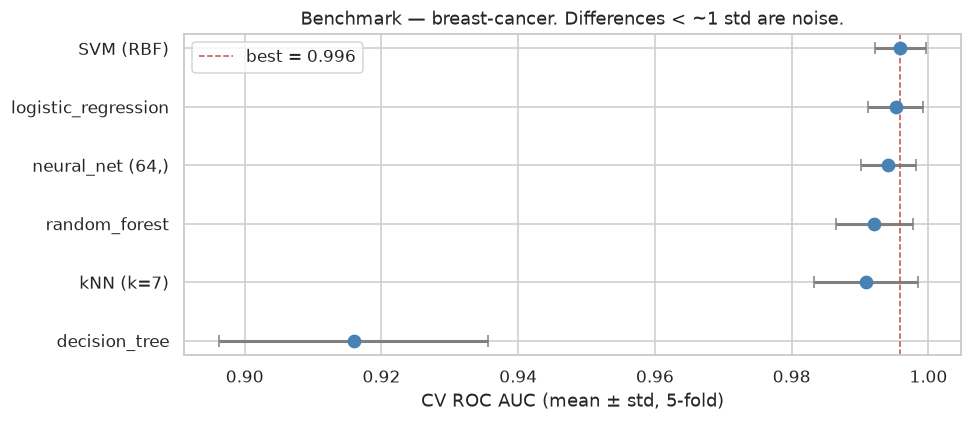

In [3]:
# Visualise: a forest plot of CV AUC with std bands — far more honest than a bar chart.
fig, ax = plt.subplots(figsize=(9, 4))
order = bench.sort_values("cv_auc")
ax.errorbar(order["cv_auc"], order["model"],
 xerr=order["std"], fmt="o", color="steelblue",
 ecolor="grey", capsize=4, lw=2, markersize=8)
ax.axvline(order["cv_auc"].max(), color="#c44e52", ls="--", lw=1,
 label=f"best = {order['cv_auc'].max():.3f}")
ax.set_xlabel("CV ROC AUC (mean ± std, 5-fold)")
ax.set_title("Benchmark — breast-cancer. Differences < ~1 std are noise.")
ax.legend()
plt.tight_layout(); plt.show()

**How to read the benchmark (the discipline from notebook 05):**
- On breast‑cancer the top models cluster within **~0.01 AUC of each other** —
 and their CV std is ~0.01–0.02. **The differences are within noise.** Don't
 crown a winner by the 4th decimal.
- The decision tree is clearly worst (high variance — needs pruning or a
 forest). Everything else is a reasonable choice.
- **Fit time** matters in production: a 50‑tree forest at 0.99 AUC may beat a
 tuned neural net at 0.992 AUC if it's 10× faster to serve.

> The honest conclusion from this benchmark: **on tabular business data, the
> model choice barely matters; the data quality, feature engineering, and
> leakage prevention matter enormously.** That's the meta‑lesson of the whole
> handbook.

## 2. The "when to use what" cheatsheet

Distilled from notebooks 02–12. Start here for any new problem.

| If your data / goal is… | Reach for… | Why (and the failure case) |
|---|---|---|
| **A strong, interpretable baseline** | **Logistic / linear regression** | fast, debuggable, coefficients readable; underfits nonlinearity |
| **Mostly linear, very high‑dim** (text, genes) | **Logistic / linear SVM** | linear models shine; few knobs |
| **Tabular, mixed types, "just want it to work"** | **Random forest / gradient boosting** | robust, little scaling, handles nonlinearity; hide leaks (notebook 08) |
| **Best accuracy, willing to tune** | **XGBoost / LightGBM** | usually tops tabular leaderboards; needs early stopping |
| **Distance‑based, small/medium dim** | **kNN** | simple, no training; needs scaling + dies in high dim (notebook 06) |
| **Clear nonlinearity, few features** | **SVM (RBF)** | principled, small memory; $O(n^2{+})$ scaling, no interpretability (notebook 10) |
| **Images / audio / text, large data** | **Deep nets (CNN/Transformer)** | universal approximators; overkill on small tabular (notebook 09) |
| **Unsupervised: visualise high‑dim** | **PCA (notebook 11)** | compression + 2D plot; unscaled data hijacks PC1 |
| **Unsupervised: round clusters** | **k‑means (notebook 12)** | fast; fails on non‑spherical shapes |
| **Unsupervised: arbitrary shapes** | **DBSCAN / spectral (notebook 12)** | density‑based; needs good `eps` |
| **"Did my change actually work?"** | **A/B test (notebook 05)** | the only honest answer; observational ≠ causal (§3) |

> **Three rules that beat the cheatsheet:**
> 1. **Start simple.** Logistic regression / a shallow tree → baseline. You'd be
> surprised how often it's enough, and it's the thing to beat.
> 2. **Beat the baseline honestly** — CV mean ± std, never a single split
> (notebook 05).
> 3. **Audit for leakage before declaring a win** — notebooks 02, 03, 08. A
> suspiciously high score is leakage until proven otherwise.

## 3. The capstone — a full end‑to‑end pipeline on Telco Churn

We run the whole workflow on a real dataset: **predict customer churn** for a
telco. This is the one place every step from the handbook is wired together.

In [4]:
# --- 1. Load + EDA ---
telco = fetch_openml(name="telco-customer-churn", version=1, as_frame=True, parser="auto").frame
id_cols = [c for c in telco.columns if "id" in c.lower()]
if id_cols: telco = telco.drop(columns=id_cols)
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")
telco = telco.dropna()
y = (telco["Churn"] == "Yes").astype(int)
X = telco.drop(columns=["Churn"])

print(f"n = {len(telco)}, churn rate = {y.mean():.3f}")
print(f"features: {X.shape[1]} ({X.select_dtypes(include=np.number).shape[1]} numeric, "
 f"{X.select_dtypes(include=['object','string']).shape[1]} categorical)")

# Quick look at the strongest univariate signal
pd.crosstab(telco["Contract"], telco["Churn"], normalize="index").round(3)

n = 7032, churn rate = 0.266
features: 19 (4 numeric, 15 categorical)


Churn,No,Yes
Contract,,
'One year',0.887,0.113
'Two year',0.972,0.028
Month-to-month,0.573,0.427


In [5]:
# --- 2. Preprocessing in a leak-free pipeline ---
cat = X.select_dtypes(include=["object", "string"]).columns.tolist()
num = X.select_dtypes(include=np.number).columns.tolist()
pre = ColumnTransformer([
 ("num", StandardScaler(), num),
 ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])

# --- 3. Benchmark three sensible models on this data ---
capstone_models = {
 "logistic_regression": LogisticRegression(max_iter=2000),
 "random_forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
 "gradient_boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}
rows = []
for name, m in capstone_models.items():
 pipe = Pipeline([("pre", pre), ("m", m)])
 s = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
 rows.append({"model": name, "cv_auc": s.mean(), "std": s.std()})
pd.DataFrame(rows).sort_values("cv_auc", ascending=False).round(3)

,model,cv_auc,std
0,logistic_regression,0.845,0.011
2,gradient_boosting,0.843,0.010
1,random_forest,0.821,0.012


best CV AUC: 0.848 with {'m__learning_rate': 0.05, 'm__max_depth': 3}


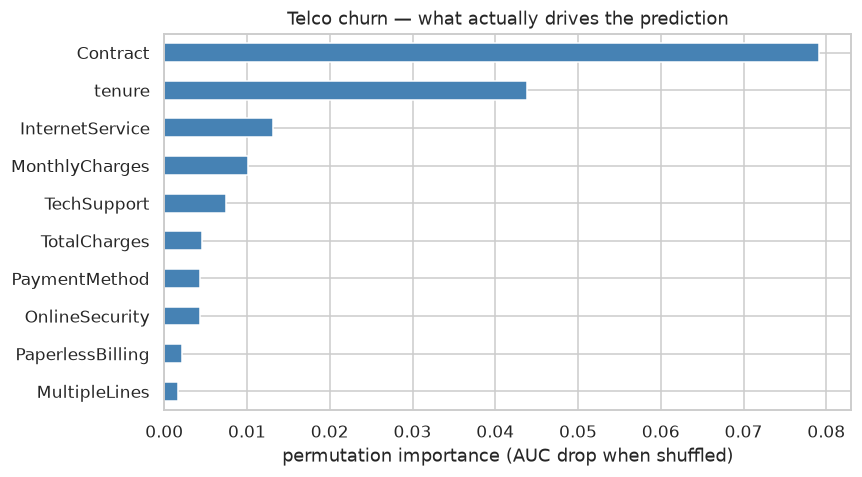

In [6]:
# --- 4. Tune the winner (gradient boosting) with GridSearchCV ---
gb_pipe = Pipeline([("pre", pre),
 ("m", GradientBoostingClassifier(random_state=42))])
param_grid = {"m__max_depth": [3, 5], "m__learning_rate": [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
gs.fit(X, y)
print(f"best CV AUC: {gs.best_score_:.3f} with {gs.best_params_}")

# --- 5. Interpret with permutation importance on a held-out split ---
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
best = gs.best_estimator_.fit(X_tr, y_tr)
perm = permutation_importance(best, X_te, y_te, n_repeats=10, random_state=42, scoring="roc_auc")
# permutation_importance is computed on the RAW input columns (one importance per
# original feature), not the post-one-hot columns.
feat_names = X.columns.tolist()
imp = pd.Series(perm.importances_mean, index=feat_names).sort_values().tail(10)
imp.plot(kind="barh", color="steelblue", figsize=(8, 4.5))
plt.xlabel("permutation importance (AUC drop when shuffled)")
plt.title("Telco churn — what actually drives the prediction")
plt.tight_layout(); plt.show()

**Reading the result:** the contract type dominates — month‑to‑month customers
churn far more than those on annual contracts. Tenure and monthly charges also
matter. This is *predictive*, not *causal* (§3): we cannot say "moving a
customer to an annual contract *will* reduce their churn" — only that the two
are associated. To answer the causal question you'd run an **A/B test**
(notebook 05): randomly offer some month‑to‑month customers an annual upgrade,
measure churn, compute the lift + CI.

> This is the capstone's closing point: **prediction ≠ decision**. The model
> tells you *who* is likely to churn; only an experiment tells you *what to do
> about it*.

## 4. Frontiers the course didn't cover

The field has moved well beyond this handbook's core. Directions worth knowing:

| Area | What it is | Where to start |
|---|---|---|
| **Gradient boosting (modern)** | XGBoost / LightGBM / CatBoost — still the tabular king | notebook 08; the libraries' docs |
| **Deep learning** | CNNs (images), Transformers (text/audio) | notebook 09; fast.ai, PyTorch tutorials |
| **Foundation models / LLMs** | giant pretrained models adapted to many tasks | "Attention is All You Need"; Hugging Face course |
| **Causal inference** | moving from *prediction* to *what‑if* questions | §3; Cunningham's *Mixtape*; Pearl's *Causality* |
| **AutoML** | automated model + hyperparameter selection | `auto-sklearn`, `FLAML`, H2O |
| **MLOps** | deploying, monitoring, retraining models in production | *Designing ML Systems* (Huyen); MLflow, Kubeflow |
| **Responsible AI** | fairness, bias auditing, privacy, explainability | §0 (societal bias collision); SHAP, Fairlearn |
| **Time series** | forecasting with temporal structure | Prophet, statsmodels, NeuralProphet |
| **Reinforcement learning** | §0 in notebook 02 — agents + rewards | Sutton & Barto, *Reinforcement Learning* |

> The meta‑skill across all of these: the fundamentals in this handbook
> (train/test discipline, leakage, leakage, leakage, honest evaluation,
> bias/variance, causation vs correlation) **don't go stale**. The model zoo
> changes every year; the analytical discipline doesn't.

## Common pitfalls & final advice

1. **Reach for the simplest thing that could work.** Complexity is a cost; pay
 it only when a baseline forces you to.
2. **The model is never the bottleneck — the data is.** A clean, well‑sampled,
 leak‑free dataset with a weak model beats a noisy, leaky dataset with a
 cutting‑edge model every time.
3. **Evaluate honestly.** CV with mean ± std; never tune on the test set; report
 effect sizes, not just significance (§5, §0 "significance" collision).
4. **Prediction is not causation.** Before acting on a model's recommendation,
 ask "would an experiment confirm this?" (§3).
5. **Document your assumptions.** Future‑you and your reviewers will thank you.
6. **Ship, measure, learn.** The model's real performance only shows up in
 production; instrument it and run A/B tests (notebook 05).

## Exercises (capstone‑level)

1. **Beat the capstone.** On Telco churn, can you beat the tuned gradient
 boosting AUC by engineering better features (e.g. `TenureGroup`,
 `ChargesPerMonth`)? Report CV mean ± std — only count a real improvement if
 the gap exceeds the std.
2. **Causal audit.** Pick the top permutation‑importance feature in §3 and argue
 whether the association is plausibly causal. What experiment would confirm
 it? What confounders (§3.2) might be at play?
3. **Wrong tool.** Run a kNN on the Telco data (one‑hot + scale). Why does it do
 worse than the tree ensembles here? (Hint: notebook 06, curse of dim.)
4. **Sensitivity to threshold.** For the capstone model, sweep the decision
 threshold and plot precision/recall. If retaining a churned customer is worth
 5× the cost of a false‑alarm retention call, which threshold maximises value?
5. **Benchmark another dataset.** Pick any OpenML dataset (e.g. `bank-marketing`)
 and run the §1 benchmark on it. Does the ranking of models change? Why?

<details><summary>Answers (click to expand)</summary>

```python
# 1: feature engineering usually gives 1-3% AUC. Anything within ~1 std is not
# a real improvement.

# 2: 'Contract=month-to-month' -> churn. Plausibly causal (lock-in reduces
# churn) but confounded: month-to-month customers may be newer, lower-tenure,
# or price-sensitive. Experiment: randomly offer annual upgrade; compare
# churn. Confounders: tenure, monthly charges, income (unmeasured).

# 3: Telco has many one-hot features after encoding (~40). kNN suffers the
# curse of dimensionality; tree ensembles handle mixed/sparse tabular better.

# 4: threshold ~0.3-0.4 usually (favor recall when catching churners is
# valuable). The exact threshold comes from the value/cost ratio, not the
# F1 maximum.

# 5: rankings DO change across datasets -- there is no universally best model.
# That's why you benchmark, not assume.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — the whole
 reference is the capstone's theoretical backbone; revisit §3 (causation),
 §5 (honest evaluation), §6 (bias/variance), §0 (the dictionary collisions).
- Textbook: Boehmke & Greenwell, *HOML* — full TOC:
 <https://bradleyboehmke.github.io/HOML/>.
- Shalev‑Shwartz & Ben‑David (2014), *Understanding Machine Learning* — the
 theory behind the bias/variance trade‑off.
- Huyen (2022), *Designing Machine Learning Systems* — for the MLOps frontier.
- Cunningham (2021), *Causal Inference: The Mixtape* — for the causal frontier:
 <https://mixtape.scunning.com/>.

---

## You've finished the handbook

You can now: frame a question, do honest EDA, build a leak‑free pipeline,
benchmark models with proper CV, tune them, interpret them, audit for
confounding, and design an experiment to turn a prediction into a decision.
That's the practical core of data science — everything else builds on it.

**Go back to `00_Theory_Reference.ipynb` whenever a term feels hazy — and when
in doubt, scale your features, audit for leakage, and run an A/B test.**